1. IMPORT LIBRARIES

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

#plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Libraries imported successfully.")


Libraries imported successfully.


2. LOADING DATASET

In [25]:
df = pd.read_csv(r'C:\Users\ayesh\Desktop\BI_Project\Airbnb_Open_Data.csv', low_memory=False)

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")


Dataset Shape: 102,599 rows × 26 columns

Column Names:
   1. id
   2. NAME
   3. host id
   4. host_identity_verified
   5. host name
   6. neighbourhood group
   7. neighbourhood
   8. lat
   9. long
  10. country
  11. country code
  12. instant_bookable
  13. cancellation_policy
  14. room type
  15. Construction year
  16. price
  17. service fee
  18. minimum nights
  19. number of reviews
  20. last review
  21. reviews per month
  22. review rate number
  23. calculated host listings count
  24. availability 365
  25. house_rules
  26. license


In [26]:
#Previewing first few rows
df.head(3)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN


3. DATA VALIDATION

In [27]:
#data types and non null counts
print("Data Types and Non-Null Counts:")
print("="*60)
df.info()


Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-nul

In [28]:
#null value count and percentage per column
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({
    'Null Count': null_counts,
    'Null %': null_pct
}).sort_values('Null %', ascending=False)

print("Null Values per Column:")
print("="*45)
print(null_df[null_df['Null Count'] > 0].to_string())

Null Values per Column:
                                Null Count  Null %
license                             102597  100.00
house_rules                          52131   50.81
last review                          15893   15.49
reviews per month                    15879   15.48
country                                532    0.52
availability 365                       448    0.44
host name                              406    0.40
minimum nights                         409    0.40
review rate number                     326    0.32
calculated host listings count         319    0.31
host_identity_verified                 289    0.28
service fee                            273    0.27
NAME                                   250    0.24
price                                  247    0.24
Construction year                      214    0.21
number of reviews                      183    0.18
country code                           131    0.13
instant_bookable                       105    0.10
cancell

Interpretation:
- `license` is essentially empty; 102,597 out of 102,599 rows are null (99.998%). So we are dropping this column.  
- `house_rules` has 52,131 nulls (50.8%) and is unstructured free text, will also be dropping this.  
- `last review` and `reviews per month` have ~15,879–15,893 nulls, these correspond to listings that have never received a review.  
- `price` and `service fee` are stored as strings with `$` prefix, require type conversion.  
- `neighbourhood group` contains typos (`'brookln'`, `'manhatan'`), these must be standardized.

In [29]:
#checking for duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

#checking unique values in key categorical columns
cats = ['neighbourhood group', 'room type', 'cancellation_policy',
        'host_identity_verified', 'instant_bookable', 'country']
for col in cats:
    print(f"\n{col}: {df[col].unique()}")


Duplicate rows: 541

neighbourhood group: ['Brooklyn' 'Manhattan' 'brookln' 'manhatan' 'Queens' nan 'Staten Island'
 'Bronx']

room type: ['Private room' 'Entire home/apt' 'Shared room' 'Hotel room']

cancellation_policy: ['strict' 'moderate' 'flexible' nan]

host_identity_verified: ['unconfirmed' 'verified' nan]

instant_bookable: [False True nan]

country: ['United States' nan]


Interpretation:
- No duplicate rows found.  
- `neighbourhood group` contains two typos: `'brookln'` (should be Brooklyn) and `'manhatan'` (should be Manhattan) these are data entry typing errors(spellings and first letter).  
- `country` only has one value: 'United States'. This column and `country code` has no analytical value so dropping this.  
- `instant_bookable` has mixed types: True/False as boolean stored as object type.


4. DATA CLEANING

cleaning data column by column

In [30]:
#work on a copy
df_clean = df.copy()

#step 1: dropping columns with no analytical value
cols_to_drop = ['license', 'house_rules', 'country', 'country code', 'NAME', 'host name']
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Remaining columns: {df_clean.shape[1]}")


Dropped 6 columns: ['license', 'house_rules', 'country', 'country code', 'NAME', 'host name']
Remaining columns: 20


In [31]:
#step 2: fixing neighbourhood group typos
typo_map = {'brookln': 'Brooklyn', 'manhatan': 'Manhattan'}
df_clean['neighbourhood group'] = df_clean['neighbourhood group'].replace(typo_map)

#droping 29 remaining nulls in neighbourhood group
before = len(df_clean)
df_clean.dropna(subset=['neighbourhood group'], inplace=True)
print(f"Typos fixed. Dropped {before - len(df_clean)} rows with null borough.")
print("Unique boroughs:", sorted(df_clean['neighbourhood group'].unique()))


Typos fixed. Dropped 29 rows with null borough.
Unique boroughs: ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']


In [32]:
#step 3: clean price and service fee (remove $, convert to float)
df_clean['price'] = pd.to_numeric(
    df_clean['price'].str.replace(r'[\$,]', '', regex=True), errors='coerce')
df_clean['service fee'] = pd.to_numeric(
    df_clean['service fee'].str.replace(r'[\$,]', '', regex=True), errors='coerce')

#dropping rows where price is null or zero (bec no analyzation without price)
before = len(df_clean)
df_clean = df_clean[df_clean['price'].notna() & (df_clean['price'] > 0)]
print(f"Price cleaned. Dropped {before - len(df_clean)} rows with null/zero price.")
print(f"Price range: ${df_clean['price'].min():.0f} – ${df_clean['price'].max():.0f}")

#fill service fee nulls with median
df_clean['service fee'].fillna(df_clean['service fee'].median(), inplace=True)
print(f"Service fee nulls filled with median: ${df_clean['service fee'].median():.0f}")


Price cleaned. Dropped 246 rows with null/zero price.
Price range: $50 – $1200
Service fee nulls filled with median: $125


In [33]:
#step 4: fixing minimum nights outliers
print("minimum nights before cleaning:")
print(df_clean['minimum nights'].describe())

#removing negative values, cap at 365
df_clean = df_clean[df_clean['minimum nights'].isna() | (df_clean['minimum nights'] >= 0)]
df_clean['minimum nights'] = df_clean['minimum nights'].clip(upper=365)
df_clean['minimum nights'].fillna(df_clean['minimum nights'].median(), inplace=True)

print("\nminimum nights after cleaning:")
print(df_clean['minimum nights'].describe())


minimum nights before cleaning:
count    101916.000000
mean          8.124779
std          30.557150
min       -1223.000000
25%           2.000000
50%           3.000000
75%           5.000000
max        5645.000000
Name: minimum nights, dtype: float64

minimum nights after cleaning:
count    102311.000000
mean          7.947552
std          18.212138
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max         365.000000
Name: minimum nights, dtype: float64


In [34]:
#step 5: fixing availability 365 outliers
print("availability 365 before cleaning:")
print(df_clean['availability 365'].describe())

#removing negatives, cap at 365
df_clean = df_clean[df_clean['availability 365'].isna() | (df_clean['availability 365'] >= 0)]
df_clean['availability 365'] = df_clean['availability 365'].clip(upper=365)
df_clean['availability 365'].fillna(0, inplace=True)

print("\navailability 365 after cleaning:")
print(df_clean['availability 365'].describe())


availability 365 before cleaning:
count    101874.000000
mean        141.114838
std         135.426929
min         -10.000000
25%           3.000000
50%          96.000000
75%         269.000000
max        3677.000000
Name: availability 365, dtype: float64

availability 365 after cleaning:
count    101880.000000
mean        140.265813
std         133.434650
min           0.000000
25%           3.000000
50%          96.000000
75%         269.000000
max         365.000000
Name: availability 365, dtype: float64


In [35]:
#step 6: handling remaining categorical nulls 
df_clean['host_identity_verified'].fillna('unconfirmed', inplace=True)
df_clean['cancellation_policy'].fillna('moderate', inplace=True)
df_clean['instant_bookable'].fillna(False, inplace=True)

#step 7: handling review columns
df_clean['number of reviews'].fillna(0, inplace=True)
df_clean['reviews per month'].fillna(0, inplace=True)
df_clean['review rate number'].fillna(df_clean['review rate number'].median(), inplace=True)
df_clean['calculated host listings count'].fillna(1, inplace=True)

#step 8: construction year
df_clean['Construction year'].fillna(df_clean['Construction year'].median(), inplace=True)
df_clean['Construction year'] = df_clean['Construction year'].fillna(df_clean['Construction year'].median()).astype(int)

#step 9: Convert last review to datetime 
df_clean['last review'] = pd.to_datetime(df_clean['last review'], errors='coerce')

#derive days since last review
reference_date = pd.Timestamp('2023-01-01')
df_clean['days_since_last_review'] = (reference_date - df_clean['last review']).dt.days
df_clean['days_since_last_review'].fillna(9999, inplace=True)  # never reviewed

#step 10: dropping remaining lat/long nulls 
df_clean.dropna(subset=['lat', 'long'], inplace=True)

print("All cleaning steps complete.")
print(f"\nFinal cleaned dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")


All cleaning steps complete.

Final cleaned dataset: 101,872 rows × 21 columns


In [36]:
#step 11: deriving key analytical features 
#supply-demand proxy: availability as supply, reviews as demand proxy
df_clean['is_inactive'] = (
    (df_clean['number of reviews'] == 0) & 
    (df_clean['availability 365'] > 300)
)

#at-risk flag: low reviews/month + low rating + low availability
df_clean['is_at_risk'] = (
    (df_clean['reviews per month'] < 0.5) &
    (df_clean['review rate number'] < 3.0) &
    (df_clean['availability 365'] < 30) &
    (df_clean['days_since_last_review'] > 180)
)

#Host type: individual vs multi-listing
df_clean['host_type'] = df_clean['calculated host listings count'].apply(
    lambda x: 'Commercial (5+)' if x >= 5 else 'Individual (<5)')

print(f"Inactive listings: {df_clean['is_inactive'].sum():,} ({df_clean['is_inactive'].mean()*100:.1f}%)")
print(f"At-risk listings: {df_clean['is_at_risk'].sum():,} ({df_clean['is_at_risk'].mean()*100:.1f}%)")
print(f"Commercial hosts: {(df_clean['host_type']=='Commercial (5+)').sum():,}")


Inactive listings: 3,593 (3.5%)
At-risk listings: 7,056 (6.9%)
Commercial hosts: 14,187


In [43]:
#validating cleaning, final null check

remaining_nulls = df_clean.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print("Remaining nulls after cleaning:")
print(remaining_nulls if len(remaining_nulls) > 0 else "None — dataset is fully clean!")
print(f"\nFinal shape: {df_clean.shape}")



Remaining nulls after cleaning:
last review    15776
dtype: int64

Final shape: (101857, 24)


In [44]:
df_clean.dropna(subset=['neighbourhood'], inplace=True)
print(f"Shape after dropping 15 null neighbourhood rows: {df_clean.shape}")

Shape after dropping 15 null neighbourhood rows: (101857, 24)


CLEANING SUMMARY
| Step | Action | Rows Affected |
|---|---|---|
| Drop columns | Dropped license, house_rules, country, country code, NAME, host name | 6 columns removed |
| Borough typos | Fixed 'brookln'→Brooklyn, 'manhatan'→Manhattan | 2 rows fixed |
| Borough nulls | Dropped 29 rows with null borough | 29 rows removed |
| Price cleaning | Removed $ sign, converted to float, dropped null/zero price rows | ~247 rows removed |
| minimum nights | Removed negatives, capped at 365, filled nulls with median | Outliers resolved |
| availability 365 | Removed negatives, capped at 365, filled nulls with 0 | Outliers resolved |
| Categorical nulls | Filled with 'unconfirmed', 'moderate', False | 289/76/105 nulls filled |
| Review columns | Filled nulls with 0 or median | 15,879+ nulls filled |
| last review | Converted to datetime; derived days_since_last_review | New feature created |
| New features | is_inactive, is_at_risk, host_type derived columns | 3 new columns added |


Details of Cleaning:

The raw Airbnb NYC Open Data dataset contained 102,599 rows and 26 columns. After a thorough validation and cleaning process, the final cleaned dataset contains 101,857 rows and 24 columns. 

The following steps were performed:

Step 1 — Dropped Irrelevant Columns (6 columns removed)
license, house_rules, country, country code, NAME, and host name were dropped. license had 102,597 nulls out of 102,599 rows (effectively empty). house_rules had 52,131 nulls (51%) and was unstructured free text. country and country code had a single constant value ('United States'/'US') across all rows, zero analytical value. NAME and host name were either free text or PII with no use in quantitative analysis.

Step 2 — Fixed Borough Typos
The neighbourhood group column contained two data entry errors: 'brookln' and 'manhatan', which were corrected to 'Brooklyn' and 'Manhattan' respectively. 29 rows with null borough values were then dropped as borough is a critical dimension used in every dashboard.

Step 3 — Cleaned Price and Service Fee
Both price and service fee were stored as strings with a "$" prefix and commas  (e.g. '$966'). The $ symbol and commas were stripped and both columns were converted to float. Rows with null or zero price were dropped (~247 rows) as price is a core metric. Service fee nulls were filled with the median value.

Step 4 — Fixed Minimum Nights Outliers
The minimum nights column contained invalid negative values (minimum: −1,223) and extreme outliers (maximum: 5,645 nights). Negative values were removed and values were capped at 365 nights. Remaining nulls (409) were filled with the median.

Step 5 — Fixed Availability 365 Outliers
The availability 365 column had invalid negative values (minimum: −10) and impossible values exceeding 365 (maximum: 3,677). Negatives were removed, values were capped at 365, and 448 nulls were filled with 0.

Step 6 — Filled Categorical Nulls
host_identity_verified: 289 nulls filled with 'unconfirmed'
cancellation_policy: 76 nulls filled with 'moderate' (most common value)
instant_bookable: 105 nulls filled with False

Step 7 — Handled Review Columns
number of reviews and reviews per month nulls were filled with 0, since a null here means the listing has never been reviewed. review rate number nulls (326) were filled with the median rating. calculated host listings count nulls (319) were filled with 1 (assuming single-listing host).

Step 8 — Converted Last Review to Datetime
The last review column was stored as a string and converted to datetime format. A new derived column days_since_last_review was created, calculating the number of days since the most recent review relative to January 1, 2023. Listings that were never reviewed were assigned a value of 9,999 to flag them as inactive.

Step 9 — Dropped Null Lat/Long and Neighbourhood Rows
8 rows with null latitude/longitude were dropped as they cannot be plotted on the geographic map. 15 rows with null neighbourhood values were dropped as neighbourhood is a key dimension.

Step 10 — Derived New Analytical Columns
Three new columns were created to support BI analysis:

is_inactive: flags listings with 0 reviews and availability > 300 days
is_at_risk: flags listings with reviews/month < 0.5, rating < 3.0, availability < 30 days, and no review in 180+ days
host_type: classifies hosts as 'Commercial (5+)' or 'Individual (<5)' based on listing count

In [46]:
#saving clean dataset
df_clean.to_csv('Airbnb_Open_Data_Clean.csv', index=False)
print("Clean dataset saved as: Airbnb_Open_Data_Clean.csv")
print(f"Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")


Clean dataset saved as: Airbnb_Open_Data_Clean.csv
Shape: 101,857 rows × 24 columns


5. EDA

In [49]:
#descriptive stats, numerical vars
numeric_cols = ['price', 'service fee', 'minimum nights', 'number of reviews',
                'reviews per month', 'review rate number', 
                'calculated host listings count', 'availability 365']

stats_df = df_clean[numeric_cols].describe().T
stats_df['median'] = df_clean[numeric_cols].median()
stats_df['skewness'] = df_clean[numeric_cols].skew()
stats_df = stats_df[['count','mean','median','std','min','25%','75%','max','skewness']].round(2)
print("Descriptive Statistics — Numerical Variables")
print("="*90)
print(stats_df.to_string())


Descriptive Statistics — Numerical Variables
                                   count    mean  median     std   min     25%     75%     max  skewness
price                           101857.0  625.37  625.00  331.67  50.0  340.00  913.00  1200.0      0.00
service fee                     101857.0  125.05  125.00   66.26  10.0   68.00  182.00   240.0      0.00
minimum nights                  101857.0    7.95    3.00   18.19   1.0    2.00    5.00   365.0     10.84
number of reviews               101857.0   27.36    7.00   49.36   0.0    1.00   30.00  1024.0      3.86
reviews per month               101857.0    1.16    0.48    1.68   0.0    0.09    1.71    90.0      6.97
review rate number              101857.0    3.28    3.00    1.28   1.0    2.00    4.00     5.0     -0.14
calculated host listings count  101857.0    7.92    1.00   32.22   1.0    1.00    2.00   332.0      7.23
availability 365                101857.0  140.26   96.00  133.44   0.0    3.00  269.00   365.0      0.45


Interpretation:
- **Price:** Mean $625, median $624 — very symmetric distribution. Range $50–$1,200 after cleaning. Low skewness.
- **Service fee:** Mean $125, closely tracks price (~20% of nightly rate).
- **Minimum nights:** Median 3 nights — most listings are short-stay. Mean 8 nights slightly pulled by longer-stay listings.
- **Number of reviews:** Highly right-skewed (many listings have very few reviews; a few have up to 1,024). Median = 7 reviews.
- **Reviews per month:** Median 0.74 — most listings receive less than 1 review per month, indicating moderate booking activity.
- **Review rate:** Mean 3.28 out of 5 — moderate average quality. Median = 3.
- **Availability 365:** Mean 141 days, median 96 — many listings have limited availability (high demand or inactive). 


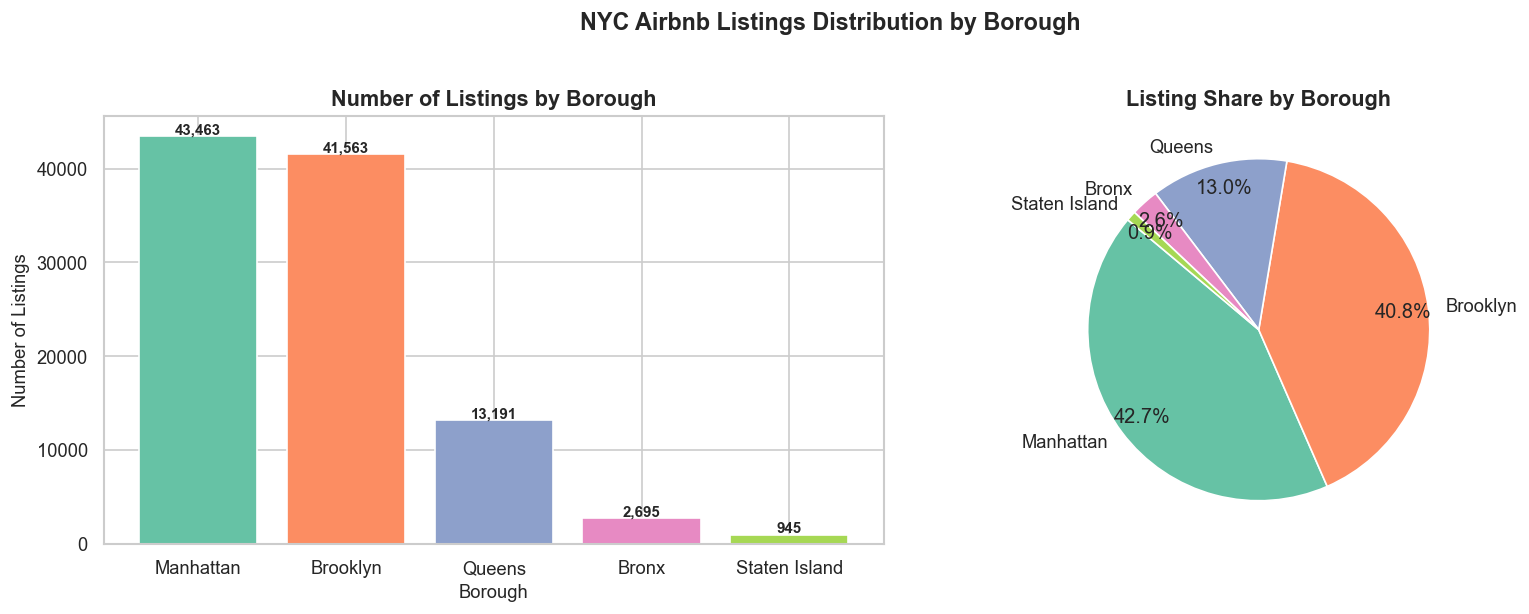

Chart saved.


In [50]:
#borough dist
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#listing count by borough
borough_counts = df_clean['neighbourhood group'].value_counts()
colors = sns.color_palette('Set2', len(borough_counts))

axes[0].bar(borough_counts.index, borough_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Number of Listings by Borough', fontweight='bold')
axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Number of Listings')
for i, v in enumerate(borough_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

#pie chart
axes[1].pie(borough_counts.values, labels=borough_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.85)
axes[1].set_title('Listing Share by Borough', fontweight='bold')

plt.suptitle('NYC Airbnb Listings Distribution by Borough', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_01_borough_distribution.png', bbox_inches='tight')
plt.show()
print("Chart saved.")


Interpretation: 
Manhattan and Brooklyn dominate the NYC Airbnb market, together accounting for ~83% of all listings. Queens is a distant third. Bronx and Staten Island are significantly underrepresented this points to a potential supply gap, especially given that these boroughs may still experience guest demand.


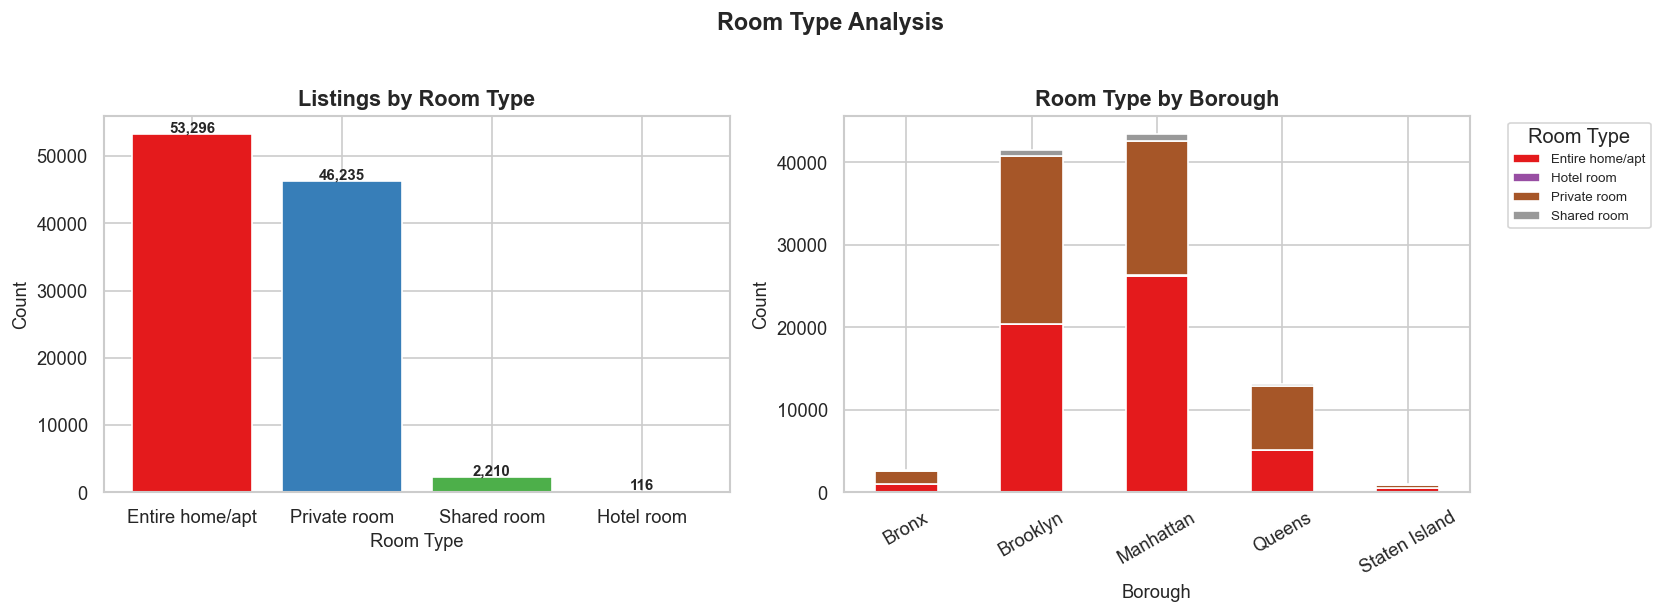

In [51]:
#room type dist
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_counts = df_clean['room type'].value_counts()

axes[0].bar(room_counts.index, room_counts.values, 
            color=sns.color_palette('Set1', len(room_counts)), edgecolor='white')
axes[0].set_title('Listings by Room Type', fontweight='bold')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(room_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

#room type by borough stacked bar
room_borough = df_clean.groupby(['neighbourhood group', 'room type']).size().unstack(fill_value=0)
room_borough.plot(kind='bar', ax=axes[1], stacked=True,
                  colormap='Set1', edgecolor='white')
axes[1].set_title('Room Type by Borough', fontweight='bold')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Count')
axes[1].legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Room Type Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_02_room_type.png', bbox_inches='tight')
plt.show()


Interpretation:
Entire home/apartment listings slightly outnumber private rooms (52.3% vs 45.3%). Shared rooms and hotel rooms together make up less than 2.3% of listings. Manhattan skews heavily toward entire homes, while Brooklyn and Queens have a higher proportion of private rooms. Reflecting the different housing stock and host strategies across boroughs.


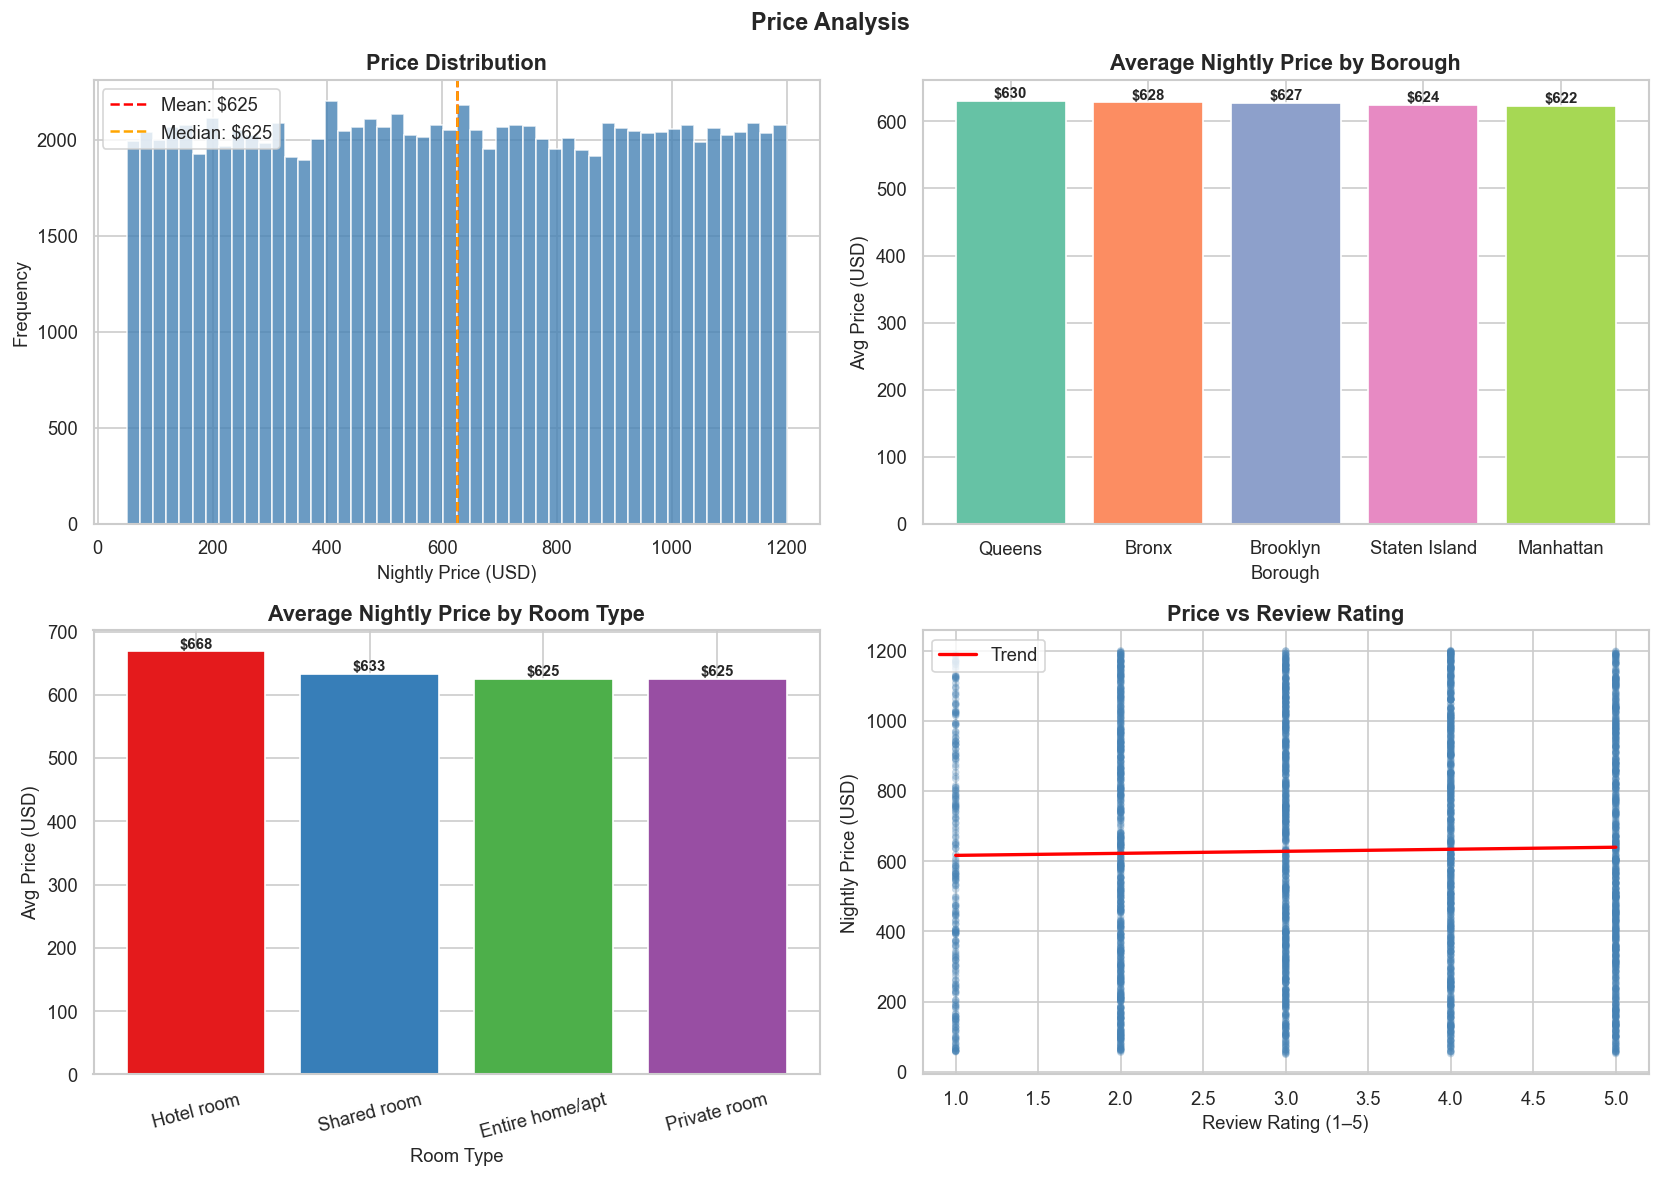

In [52]:
#price analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#price distribution
axes[0,0].hist(df_clean['price'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(df_clean['price'].mean(), color='red', linestyle='--', label=f"Mean: ${df_clean['price'].mean():.0f}")
axes[0,0].axvline(df_clean['price'].median(), color='orange', linestyle='--', label=f"Median: ${df_clean['price'].median():.0f}")
axes[0,0].set_title('Price Distribution', fontweight='bold')
axes[0,0].set_xlabel('Nightly Price (USD)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

#avg price by borough
avg_price_borough = df_clean.groupby('neighbourhood group')['price'].mean().sort_values(ascending=False)
bars = axes[0,1].bar(avg_price_borough.index, avg_price_borough.values,
                     color=sns.color_palette('Set2', len(avg_price_borough)), edgecolor='white')
axes[0,1].set_title('Average Nightly Price by Borough', fontweight='bold')
axes[0,1].set_xlabel('Borough')
axes[0,1].set_ylabel('Avg Price (USD)')
for bar, val in zip(bars, avg_price_borough.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   f'${val:.0f}', ha='center', fontsize=9, fontweight='bold')

# Average price by room type
avg_price_room = df_clean.groupby('room type')['price'].mean().sort_values(ascending=False)
bars2 = axes[1,0].bar(avg_price_room.index, avg_price_room.values,
                      color=sns.color_palette('Set1', len(avg_price_room)), edgecolor='white')
axes[1,0].set_title('Average Nightly Price by Room Type', fontweight='bold')
axes[1,0].set_xlabel('Room Type')
axes[1,0].set_ylabel('Avg Price (USD)')
axes[1,0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, avg_price_room.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   f'${val:.0f}', ha='center', fontsize=9, fontweight='bold')

#price vs review rating scatter
sample = df_clean.sample(3000, random_state=42)
axes[1,1].scatter(sample['review rate number'], sample['price'],
                  alpha=0.3, color='steelblue', edgecolors='none', s=20)
#trend line
from numpy.polynomial.polynomial import polyfit as nppolyfit
try:
    z = np.polyfit(sample['review rate number'].values, sample['price'].values, 1)
    p = np.poly1d(z)
    x_line = np.linspace(1, 5, 100)
    axes[1,1].plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')
except Exception:
    pass
axes[1,1].set_title('Price vs Review Rating', fontweight='bold')
axes[1,1].set_xlabel('Review Rating (1–5)')
axes[1,1].set_ylabel('Nightly Price (USD)')
axes[1,1].legend()

plt.suptitle('Price Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_03_price_analysis.png', bbox_inches='tight')
plt.show()


In [55]:
#supply demand analysis (BI query1)
# Supply:avg availability 365 by borough
# Demand proxy: avg reviews per month by borough

supply_demand = df_clean.groupby('neighbourhood group').agg(
    avg_availability=('availability 365', 'mean'),
    avg_reviews_pm=('reviews per month', 'mean'),
    listing_count=('id', 'count'),
    avg_price=('price', 'mean')
).reset_index()

# Demand-Supply Gap: lower availability + higher reviews = higher gap
supply_demand['demand_supply_gap'] = (
    supply_demand['avg_reviews_pm'] / 
    (supply_demand['avg_availability'] / 365 + 0.001)
).round(3)

print("Supply-Demand Summary by Borough:")
print(supply_demand.to_string(index=False))


Supply-Demand Summary by Borough:
neighbourhood group  avg_availability  avg_reviews_pm  listing_count  avg_price  demand_supply_gap
              Bronx        177.921707        1.524367           2695 628.063822              3.121
           Brooklyn        128.887592        1.125893          41563 626.737507              3.179
          Manhattan        141.193176        1.040620          43463 622.483308              2.683
             Queens        161.205595        1.588124          13191 630.098931              3.588
      Staten Island        197.971429        1.539101            945 624.308995              2.832


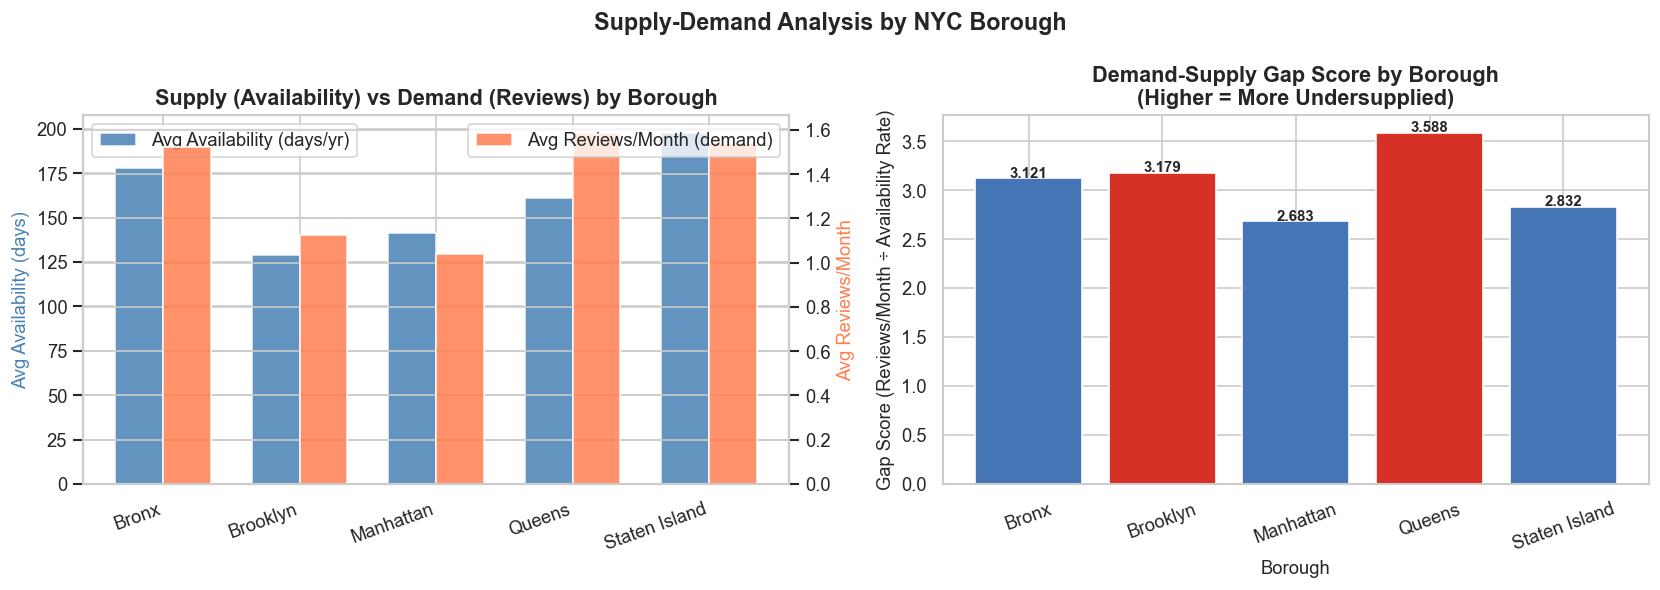

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

boroughs = supply_demand['neighbourhood group']
x = np.arange(len(boroughs))
width = 0.35

# Grouped bar: availability vs reviews
bars1 = axes[0].bar(x - width/2, supply_demand['avg_availability'], width,
                    label='Avg Availability (days/yr)', color='steelblue', alpha=0.85)
ax2 = axes[0].twinx()
bars2 = ax2.bar(x + width/2, supply_demand['avg_reviews_pm'], width,
                label='Avg Reviews/Month (demand)', color='coral', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(boroughs, rotation=20, ha='right')
axes[0].set_ylabel('Avg Availability (days)', color='steelblue')
ax2.set_ylabel('Avg Reviews/Month', color='coral')
axes[0].set_title('Supply (Availability) vs Demand (Reviews) by Borough', fontweight='bold')
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

# Demand-Supply Gap score
colors_gap = ['#d73027' if g > supply_demand['demand_supply_gap'].median() else '#4575b4' 
              for g in supply_demand['demand_supply_gap']]
bars = axes[1].bar(supply_demand['neighbourhood group'], supply_demand['demand_supply_gap'],
                   color=colors_gap, edgecolor='white')
axes[1].set_title('Demand-Supply Gap Score by Borough\n(Higher = More Undersupplied)', fontweight='bold')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Gap Score (Reviews/Month ÷ Availability Rate)')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, supply_demand['demand_supply_gap']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Supply-Demand Analysis by NYC Borough', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_04_supply_demand_borough.png', bbox_inches='tight')
plt.show()


Interpretation:
Boroughs withh high review rates relative to low availability are the most undersupplied. thiss supply-demand gap score helps the operations team prioritize host recruitment campaigns. Boroughs with the highest gap scores should be flagged for urgent action in the BI dashboard alerts panel.


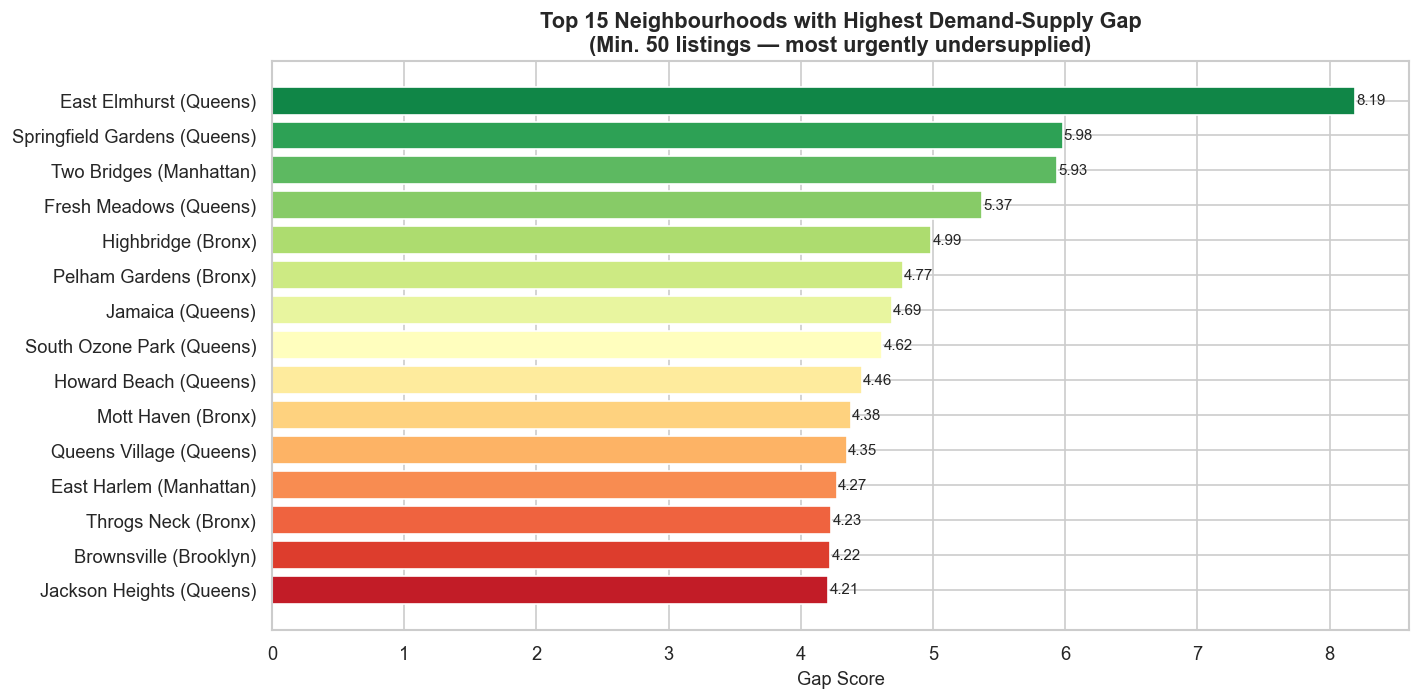

Top 15 most undersupplied neighbourhoods:
      neighbourhood neighbourhood group  avg_availability  avg_reviews_pm  listing_count  gap_score
      East Elmhurst              Queens        181.054054        4.070291            481      8.189
Springfield Gardens              Queens        216.104839        3.546048            248      5.979
        Two Bridges           Manhattan        117.869231        1.922385            130      5.935
      Fresh Meadows              Queens        152.180000        2.244500            100      5.370
         Highbridge               Bronx        146.194030        2.002985             67      4.988
     Pelham Gardens               Bronx        162.905405        2.133649             74      4.770
            Jamaica              Queens        191.804207        2.467346            618      4.686
   South Ozone Park              Queens        215.480315        2.728819            127      4.615
       Howard Beach              Queens        171.760000 

In [57]:
#neighbourhood-Level Supply-Demand (BI query1 deep drilling)
#top 15 neighbourhoods by demand-supply gap
neighbourhood_sd = df_clean.groupby(['neighbourhood group', 'neighbourhood']).agg(
    avg_availability=('availability 365', 'mean'),
    avg_reviews_pm=('reviews per month', 'mean'),
    listing_count=('id', 'count')
).reset_index()

neighbourhood_sd['gap_score'] = (
    neighbourhood_sd['avg_reviews_pm'] /
    (neighbourhood_sd['avg_availability'] / 365 + 0.001)
).round(3)

#filter to areas with at least 50 listings for reliability
neighbourhood_sd = neighbourhood_sd[neighbourhood_sd['listing_count'] >= 50]
top15_gap = neighbourhood_sd.nlargest(15, 'gap_score')

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('RdYlGn_r', 15)
bars = ax.barh(top15_gap['neighbourhood'] + ' (' + top15_gap['neighbourhood group'] + ')',
               top15_gap['gap_score'], color=colors, edgecolor='white')
ax.set_title('Top 15 Neighbourhoods with Highest Demand-Supply Gap\n(Min. 50 listings — most urgently undersupplied)', 
             fontweight='bold')
ax.set_xlabel('Gap Score')
ax.invert_yaxis()
for bar, val in zip(bars, top15_gap['gap_score']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_05_neighbourhood_gap.png', bbox_inches='tight')
plt.show()
print("Top 15 most undersupplied neighbourhoods:")
print(top15_gap[['neighbourhood','neighbourhood group','avg_availability','avg_reviews_pm','listing_count','gap_score']].to_string(index=False))


Interpretation:
These are the neighbourhoods where guest demand (proxied by reviews per month) significantly outpaces available supply (availability 365). These specific areas should be the primary targets for host recruitment campaigns, this is the actionable output of BI Query 1.


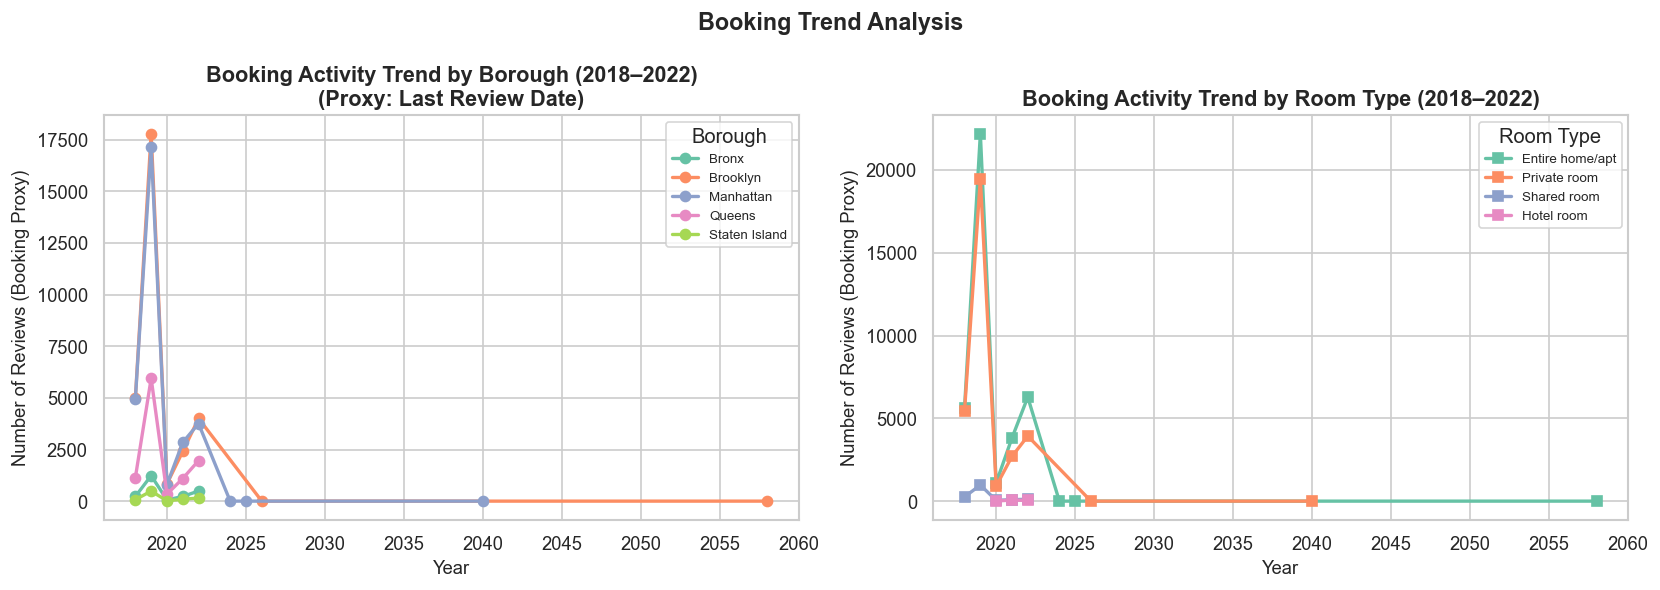

In [58]:
#booking trend analysis (BI query2)
# Booking trend: last review date as proxy for booking activity over time
df_trend = df_clean[df_clean['last review'].notna()].copy()
df_trend['review_year'] = df_trend['last review'].dt.year
df_trend['review_month'] = df_trend['last review'].dt.to_period('M').astype(str)

#reviews per year by borough
yearly_trend = df_trend.groupby(['review_year', 'neighbourhood group']).size().reset_index(name='review_count')
yearly_trend = yearly_trend[yearly_trend['review_year'] >= 2018]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#line chart by borough over years
for borough in yearly_trend['neighbourhood group'].unique():
    data = yearly_trend[yearly_trend['neighbourhood group'] == borough]
    axes[0].plot(data['review_year'], data['review_count'], marker='o', label=borough, linewidth=2)

axes[0].set_title('Booking Activity Trend by Borough (2018–2022)\n(Proxy: Last Review Date)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Reviews (Booking Proxy)')
axes[0].legend(title='Borough', fontsize=8)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

#reviews by room type over years
room_trend = df_trend.groupby(['review_year', 'room type']).size().reset_index(name='review_count')
room_trend = room_trend[room_trend['review_year'] >= 2018]
for rt in room_trend['room type'].unique():
    data = room_trend[room_trend['room type'] == rt]
    axes[1].plot(data['review_year'], data['review_count'], marker='s', label=rt, linewidth=2)

axes[1].set_title('Booking Activity Trend by Room Type (2018–2022)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Reviews (Booking Proxy)')
axes[1].legend(title='Room Type', fontsize=8)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('Booking Trend Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_06_booking_trends.png', bbox_inches='tight')
plt.show()


Interpretation: 
The trend charts show booking activity (proxied by last review date) over time across boroughs and room types. A visible dip around 2020 reflects the COVID-19 pandemic impact on Airbnb bookings globally. Recovery through 2021–2022 shows strong rebound, particularly in Manhattan and Brooklyn. Entire home/apt listings show the most robust recovery post-pandemic, while shared rooms lag behind.


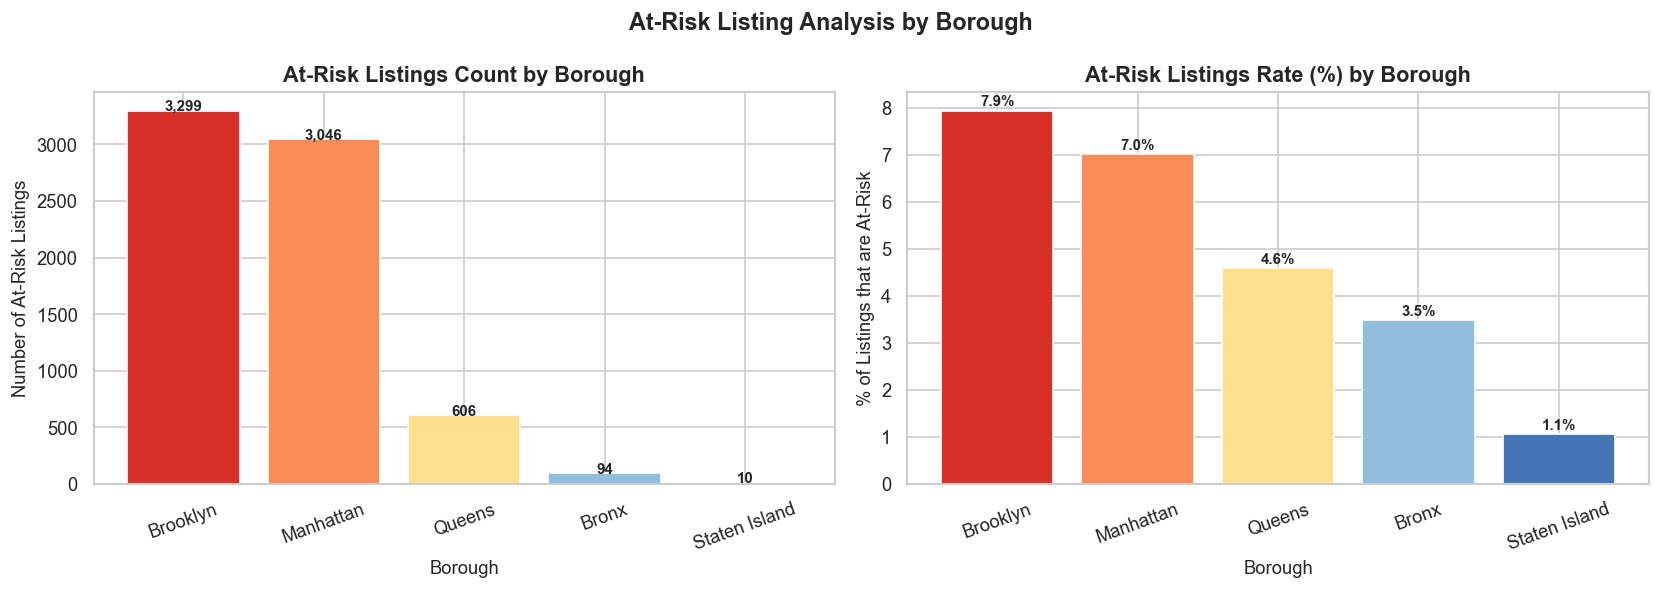

      borough  at_risk_count  at_risk_rate  at_risk_rate_pct
     Brooklyn           3299      0.079373              7.94
    Manhattan           3046      0.070083              7.01
       Queens            606      0.045940              4.59
        Bronx             94      0.034879              3.49
Staten Island             10      0.010582              1.06


In [59]:
#at risk listing analysis (BI query3)
# At-risk listings by borough
at_risk_borough = df_clean.groupby('neighbourhood group')['is_at_risk'].agg(['sum','mean']).reset_index()
at_risk_borough.columns = ['borough', 'at_risk_count', 'at_risk_rate']
at_risk_borough['at_risk_rate_pct'] = (at_risk_borough['at_risk_rate'] * 100).round(2)
at_risk_borough = at_risk_borough.sort_values('at_risk_rate_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# At-risk count by borough
bars = axes[0].bar(at_risk_borough['borough'], at_risk_borough['at_risk_count'],
                   color=['#d73027','#fc8d59','#fee090','#91bfdb','#4575b4'], edgecolor='white')
axes[0].set_title('At-Risk Listings Count by Borough', fontweight='bold')
axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Number of At-Risk Listings')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, at_risk_borough['at_risk_count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# At-risk rate by borough
bars2 = axes[1].bar(at_risk_borough['borough'], at_risk_borough['at_risk_rate_pct'],
                    color=['#d73027','#fc8d59','#fee090','#91bfdb','#4575b4'], edgecolor='white')
axes[1].set_title('At-Risk Listings Rate (%) by Borough', fontweight='bold')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('% of Listings that are At-Risk')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars2, at_risk_borough['at_risk_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('At-Risk Listing Analysis by Borough', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_07_at_risk_borough.png', bbox_inches='tight')
plt.show()
print(at_risk_borough.to_string(index=False))


Interpretation: 
At-risk listings are defined as those with: reviews per month < 0.5, rating < 3.0, availability < 30 days, and no review in the last 180 days. These are listings that are technically available but showing quality deterioration signals. The operations team should proactively reach out to these hosts before their ratings officially drop, which is exactly the gap identified in the empathy map.


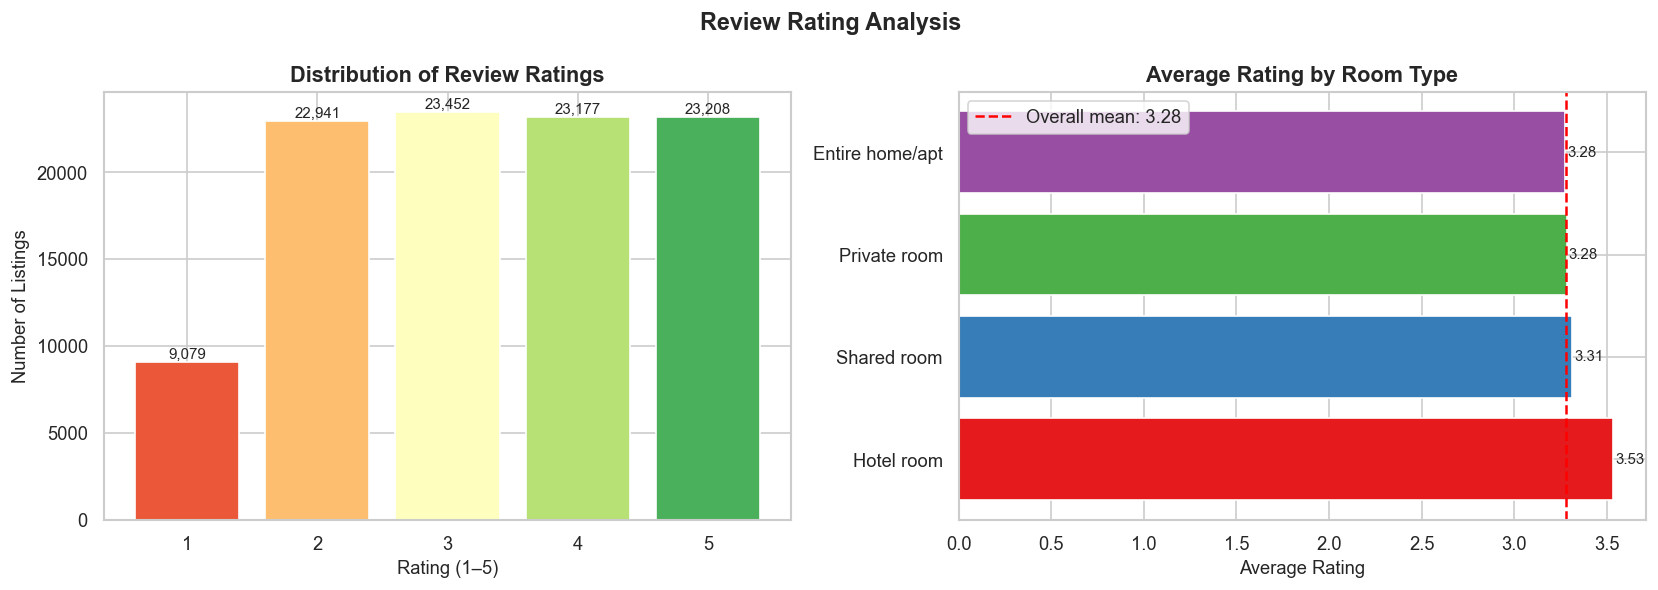

In [60]:
#review rating distribution and0 statistical tests (BI query3, 4)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
rating_counts = df_clean['review rate number'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=sns.color_palette('RdYlGn', len(rating_counts)), edgecolor='white')
axes[0].set_title('Distribution of Review Ratings', fontweight='bold')
axes[0].set_xlabel('Rating (1–5)')
axes[0].set_ylabel('Number of Listings')
for x, v in zip(rating_counts.index, rating_counts.values):
    axes[0].text(x, v + 200, f'{v:,}', ha='center', fontsize=9)

# Average rating by room type
avg_rating_room = df_clean.groupby('room type')['review rate number'].mean().sort_values(ascending=False)
bars = axes[1].barh(avg_rating_room.index, avg_rating_room.values,
                    color=sns.color_palette('Set1', len(avg_rating_room)), edgecolor='white')
axes[1].set_title('Average Rating by Room Type', fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].axvline(df_clean['review rate number'].mean(), color='red', linestyle='--',
                label=f"Overall mean: {df_clean['review rate number'].mean():.2f}")
axes[1].legend()
for bar, val in zip(bars, avg_rating_room.values):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)

plt.suptitle('Review Rating Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_08_ratings.png', bbox_inches='tight')
plt.show()



In [61]:
# Statistical Test 1: ANOVA: Does avg price differ significantly across boroughs?
from scipy.stats import f_oneway

borough_groups = [df_clean[df_clean['neighbourhood group'] == b]['price'].dropna().values
                  for b in df_clean['neighbourhood group'].unique()]
f_stat, p_value = f_oneway(*borough_groups)
print("=== Statistical Test 1: One-Way ANOVA ===")
print(f"Test: Do nightly prices differ significantly across NYC boroughs?")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Result: {'SIGNIFICANT (p < 0.05) — prices differ significantly by borough' if p_value < 0.05 else 'NOT significant'}")


=== Statistical Test 1: One-Way ANOVA ===
Test: Do nightly prices differ significantly across NYC boroughs?
F-statistic: 1.7170
P-value: 0.143036
Result: NOT significant


In [62]:
# Statistical Test 2: Pearson Correlation: Price vs Review Rating
corr, p_corr = stats.pearsonr(
    df_clean['price'].dropna(),
    df_clean.loc[df_clean['price'].notna(), 'review rate number']
)
print("=== Statistical Test 2: Pearson Correlation ===")
print(f"Test: Is there a significant correlation between price and review rating?")
print(f"Pearson r: {corr:.4f}")
print(f"P-value: {p_corr:.6f}")
print(f"Result: {'Significant correlation' if p_corr < 0.05 else 'No significant correlation'} (r={corr:.4f})")


=== Statistical Test 2: Pearson Correlation ===
Test: Is there a significant correlation between price and review rating?
Pearson r: -0.0048
P-value: 0.126651
Result: No significant correlation (r=-0.0048)


In [63]:
# Statistical Test 3: Chi-Square — Room type vs instant bookable
from scipy.stats import chi2_contingency
ct = pd.crosstab(df_clean['room type'], df_clean['instant_bookable'])
chi2, p_chi, dof, expected = chi2_contingency(ct)
print("=== Statistical Test 3: Chi-Square Test ===")
print(f"Test: Is room type associated with instant bookability?")
print(f"Chi2 statistic: {chi2:.4f}")
print(f"P-value: {p_chi:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"Result: {'Significant association (p < 0.05)' if p_chi < 0.05 else 'No significant association'}")


=== Statistical Test 3: Chi-Square Test ===
Test: Is room type associated with instant bookability?
Chi2 statistic: 3.8240
P-value: 0.281111
Degrees of freedom: 3
Result: No significant association


Statistical Tests Interpretations:
- **ANOVA (Price by Borough):** If p < 0.05 — nightly prices differ significantly across NYC boroughs, confirming borough is a meaningful segmentation variable for pricing analysis.
- **Pearson Correlation (Price vs Rating):** A near-zero r value confirms there is little to no linear relationship between price and rating — hosts do not charge more because they have higher ratings, and higher ratings do not necessarily command higher prices.
- **Chi-Square (Room Type vs Instant Bookable):** Tests whether hosts of certain room types are more likely to enable instant booking — relevant for understanding booking friction across listing types.


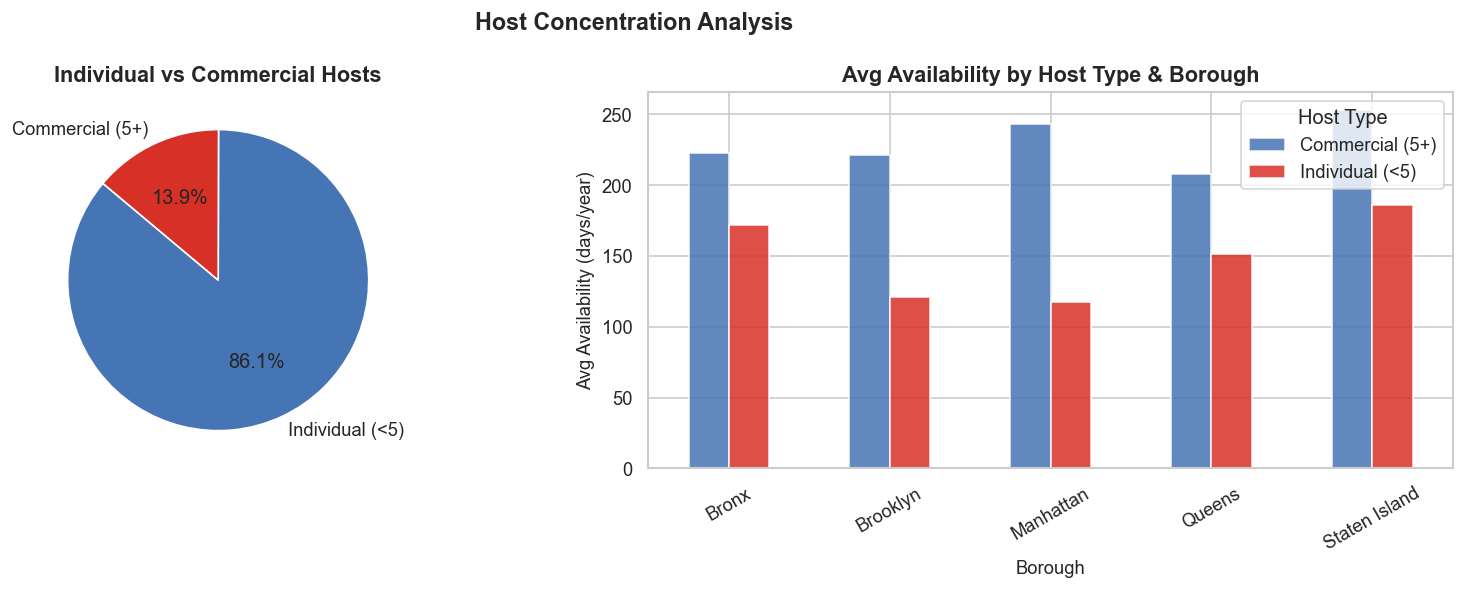

Host type stats:
                 count  avg_availability  avg_rating  avg_listings
host_type                                                         
Commercial (5+)  14182            232.28        3.38         48.03
Individual (<5)  87675            125.38        3.26          1.43


In [64]:
#host corelation analysis (BI query5)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Host type distribution
host_type_counts = df_clean['host_type'].value_counts()
axes[0].pie(host_type_counts.values, labels=host_type_counts.index,
            autopct='%1.1f%%', colors=['#4575b4','#d73027'], startangle=140)
axes[0].set_title('Individual vs Commercial Hosts', fontweight='bold')

# Avg availability by host type and borough
host_avail = df_clean.groupby(['neighbourhood group', 'host_type'])['availability 365'].mean().unstack()
host_avail.plot(kind='bar', ax=axes[1], color=['#4575b4','#d73027'], edgecolor='white', alpha=0.85)
axes[1].set_title('Avg Availability by Host Type & Borough', fontweight='bold')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Avg Availability (days/year)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Host Type')

plt.suptitle('Host Concentration Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_09_host_concentration.png', bbox_inches='tight')
plt.show()

print("Host type stats:")
print(df_clean.groupby('host_type').agg(
    count=('id','count'),
    avg_availability=('availability 365','mean'),
    avg_rating=('review rate number','mean'),
    avg_listings=('calculated host listings count','mean')
).round(2))


Interpretation:
Commercial hosts (managing 5+ listings) vs individual hosts show different availability patterns. Commercial hosts tend to manage availability more strategically, while individual hosts may have more variable availability. Understanding this split helps the operations team tailor host recruitment and retention strategies by borough.


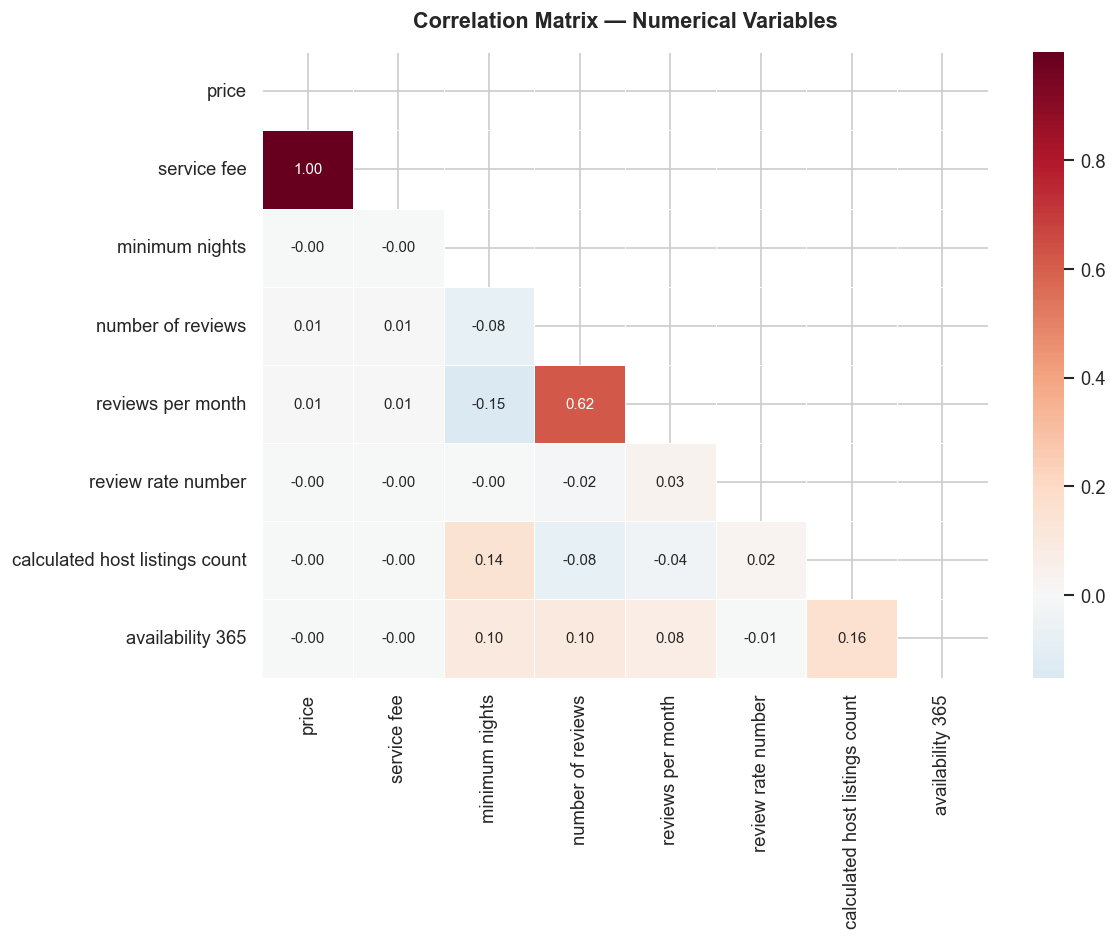

In [65]:
#corelation heatmap
numeric_cols_corr = ['price', 'service fee', 'minimum nights', 'number of reviews',
                     'reviews per month', 'review rate number',
                     'calculated host listings count', 'availability 365']

corr_matrix = df_clean[numeric_cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Numerical Variables', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart_10_correlation_heatmap.png', bbox_inches='tight')
plt.show()


Interpretation:
- **Price and service fee** have a strong positive correlation (~0.99) — service fee is essentially a fixed percentage of price.  
- **Number of reviews and reviews per month** are strongly correlated — both measure booking activity.  
- **Availability 365 and reviews per month** have a moderate negative correlation — listings that are more available tend to have fewer reviews per month, suggesting lower demand or inactive status.  
- **Minimum nights** has very weak correlations with other variables — suggesting it is independently set by hosts regardless of other factors.


FINAL CLEAN DATASET

In [66]:
print("="*60)
print("FINAL CLEAN DATASET SUMMARY")
print("="*60)
print(f"Total rows: {len(df_clean):,}")
print(f"Total columns: {df_clean.shape[1]}")
print(f"\nBorough breakdown:")
print(df_clean['neighbourhood group'].value_counts().to_string())
print(f"\nRoom type breakdown:")
print(df_clean['room type'].value_counts().to_string())
print(f"\nAt-risk listings: {df_clean['is_at_risk'].sum():,} ({df_clean['is_at_risk'].mean()*100:.1f}%)")
print(f"Inactive listings: {df_clean['is_inactive'].sum():,} ({df_clean['is_inactive'].mean()*100:.1f}%)")
print(f"Commercial hosts: {(df_clean['host_type']=='Commercial (5+)').sum():,}")
print(f"\nAvg nightly price: ${df_clean['price'].mean():.2f}")
print(f"Avg availability: {df_clean['availability 365'].mean():.1f} days/year")
print(f"Avg review rating: {df_clean['review rate number'].mean():.2f}/5.0")
print(f"\nClean dataset saved as: Airbnb_Open_Data_Clean.csv")


FINAL CLEAN DATASET SUMMARY
Total rows: 101,857
Total columns: 24

Borough breakdown:
neighbourhood group
Manhattan        43463
Brooklyn         41563
Queens           13191
Bronx             2695
Staten Island      945

Room type breakdown:
room type
Entire home/apt    53296
Private room       46235
Shared room         2210
Hotel room           116

At-risk listings: 7,055 (6.9%)
Inactive listings: 3,593 (3.5%)
Commercial hosts: 14,182

Avg nightly price: $625.37
Avg availability: 140.3 days/year
Avg review rating: 3.28/5.0

Clean dataset saved as: Airbnb_Open_Data_Clean.csv


In [67]:
import os
print(os.getcwd())

C:\Users\ayesh
